In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

connect all files 

In [2]:
products = pd.read_csv("Data_files/Products.csv")
Product_cat = pd.read_csv("Data_files/ProductCategories.csv")
Store_D = pd.read_csv("Data_files/StoreDetail.csv")
Store_S = pd.read_csv("Data_files/StoreSales.csv")
Customer = pd.read_csv("Data_files/customer_list.csv")

In [3]:
# putting togeth sales with store details
sales_merged = Store_S.merge(
    Store_D,
    on="Store ID",
    how="left")



# Filtering, Sorting & Exploration

1. Create a list of all transactions from January 2024, sorted by sale amount from highest to lowest.
Which transactions had a sale amount greater than $500?

In [4]:
sales_merged = Store_S.merge(
    Store_D,
    on="Store ID",
    how="left")

# change transaction date colmn into date format
sales_merged["Transaction Date"] =pd.to_datetime(sales_merged["Transaction Date"])

# filter for jan 2024
jan_2024 = sales_merged[
    (sales_merged["Transaction Date"].dt.year == 2024) &
    (sales_merged["Transaction Date"].dt.month ==1)]

#sort transactions from highest to lowest sale amount
jan_2024 = jan_2024.sort_values(by="Sale Amount",ascending=False)

# show jan 2024 transactions 
jan_2024.style.hide(axis="index")
# =======================================
# show only transaction with sale amounts more than 500
high_amount = jan_2024[
    jan_2024["Sale Amount"] > 500]

# show amounts more than 500
high_amount.style.hide(axis="index")

Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
2024-01-01 00:00:00,726,nan,105341-IT,1763.700000,Orlando,Florida,Lana Ilana,South,Andy Gisselquist
2024-01-31 00:00:00,822,nan,105341-IT,1763.700000,Orono,Maine,Erbayne Middleton,Northeast,Michael Jarvis
2024-01-18 00:00:00,736,nan,105341-IT,1763.700000,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
2024-01-10 00:00:00,823,337.000000,105341-IT,1763.700000,South Portland,Maine,Erbayne Middleton,Northeast,Michael Jarvis
2024-01-27 00:00:00,701,nan,105341-IT,1763.700000,Aurora,Colorado,Jim Heck,West,Cassie Chambers
2024-01-09 00:00:00,872,nan,105341-IT,1763.700000,Waterbury,Connecticut,Ellen Lemon,East,Ana Jilani
2024-01-09 00:00:00,731,nan,105341-IT,1763.700000,Annapolis,Maryland,Shruti Reddy,Northeast,Michael Jarvis
2024-01-27 00:00:00,736,nan,105341-IT,1763.700000,North Harford,Maryland,Shruti Reddy,Northeast,Michael Jarvis
2024-01-31 00:00:00,729,nan,105326-IT,1717.700000,Tampa,Florida,Lana Ilana,South,Andy Gisselquist
2024-01-10 00:00:00,705,nan,105325-IT,1717.700000,Denver,Colorado,Jim Heck,West,Cassie Chambers


2. Find all products whose product number begins with 10525. What category and subcategory do they
belong

In [5]:
# Merge products table with product category table
product_data = products.merge(
    Product_cat,
    on=["CategoryID", "SubcategoryID"],
    how="left")

# Filter products where product number starts with 10525
products_10525 = product_data[
    product_data["Prod Num"].astype(str).str.startswith("10525")]

# Select relevant columns
products_10525 = products_10525[
    [
        "Prod Num",
        "Product",
        "Category",
        "Subcategory"]]

# Remove duplicate rows
products_10525 = products_10525.drop_duplicates()

# Display results
products_10525.style.hide(axis="index")

Prod Num,Product,Category,Subcategory
105250-IT,Realme Pad,Technology & Accessories,Tablets
105251-IT,Lenovo Tab P12 Pro,Technology & Accessories,Tablets
105252-IT,Microsoft Surface Pro 9,Technology & Accessories,Tablets
105253-IT,"Apple iPad Pro (12.9-inch, M2)",Technology & Accessories,Tablets
105254-IT,Chuwi HiPad Max,Technology & Accessories,Tablets
105255-IT,Lenovo Yoga Smart Tab,Technology & Accessories,Tablets
105256-IT,ASUS Vivobook 13 Slate OLED,Technology & Accessories,Tablets
105257-IT,Samsung Galaxy Tab S9 Ultra,Technology & Accessories,Tablets
105258-IT,Apple iPad Air (10.9-inch),Technology & Accessories,Tablets
105259-IT,Teclast T40 Pro,Technology & Accessories,Tablets


3. Which stores in your assigned territories had at least one transaction with a sale amount over
$1,000? How many such transactions did each store have?

In [6]:
# Merge sales data with store details
sales_merged = Store_S.merge(
    Store_D,
    on="Store ID",
    how="left")

# Filter only Maine and Maryland territories
territory_sales = sales_merged[
    sales_merged["State"].isin(["Maine", "Maryland"])]

# Keep only transactions greater than $1,000
high_value_sales = territory_sales[
    territory_sales["Sale Amount"] > 1000]

# Group by store and count the number of transactions
store_transaction_counts = high_value_sales.groupby(
    ["State", "Store ID", "Store Location"]
)["Sale Amount"].count().reset_index()

# Rename count column for easier understanding
store_transaction_counts = store_transaction_counts.rename(
    columns={"Sale Amount": "Transactions more than $1,000"})

# Sort stores from highest transaction count to lowest
store_transaction_counts = store_transaction_counts.sort_values(
    by="Transactions more than $1,000",
    ascending=False)

# show results
store_transaction_counts.style.hide(axis="index")

State,Store ID,Store Location,"Transactions more than $1,000"
Maryland,736,North Harford,2241
Maryland,734,Germantown,153
Maine,823,South Portland,97
Maine,820,Kennebunkport,93
Maine,818,Bangor,93
Maryland,737,Parkville,91
Maryland,739,Ridgely,90
Maryland,733,Baltimore,89
Maryland,735,Howard,86
Maine,822,Orono,85


# Aggregation & NumPy

# What is the total sales revenue across all in-store transactions in the dataset? What is the average transaction amount? What is the standard deviation?

In [9]:
# Total sale revenues
total_revenue = Store_S["Sale Amount"].sum()

#calculate avg transaction amount using mean
avg_transactions = Store_S["Sale Amount"].mean()

#finding standard deviation of transaction amounts
transaction_dev = Store_S["Sale Amount"].std()

print("Total Sale Revenue: $", round(total_revenue,2))
print("Average Transaction Amount: $", round(avg_transactions,2))
print("Standard Deviation: $", round(transaction_dev,2))

Total Sale Revenue: $ 45370048.85
Average Transaction Amount: $ 135.38
Standard Deviation: $ 279.72


# Which stores had total revenue above the average store revenue across the full dataset? (Hint: use np.mean().

In [15]:
# join sales data with store details
sales_merged = Store_S.merge(
    Store_D,
    on="Store ID",
    how="left")

# total revenue for each store
store_revenue = sales_merged.groupby(
    ["Store ID","Store Location","State"])["Sale Amount"].sum().reset_index()

# avg store revenues
avg_store_revenue = np.mean(store_revenue["Sale Amount"])

# pulling stores with revenue above the average
above_average_stores = store_revenue[store_revenue["Sale Amount"] > avg_store_revenue]

# print show the avg store revenue using np.mean 
print(
    "Average Store Revenue: $",
    round(avg_store_revenue, 2)
)

above_average_stores



Average Store Revenue: $ 408739.18


,Store ID,Store Location,State,Sale Amount
4,705,Denver,Colorado,917471.53
8,709,Greeley,Colorado,640368.11
23,724,Miami,Florida,618846.25
27,728,Tallahassee,Florida,541670.66
33,734,Germantown,Maryland,584675.92
35,736,North Harford,Maryland,8708119.00
55,817,Worcester,Massachusetts,602183.44
73,835,Newark,New Jersey,623163.53
76,838,Trenton,New Jersey,597565.68
85,847,Rochester,New York,607148.21


# What is the total revenue for each product category across all territories, sorted from highest to lowest? Which category has the most individual transactions

In [16]:
# join products table with category table
product_data = products.merge(
    Product_cat,
    on=["CategoryID","SubcategoryID"],
    how="left")

# now join sales table with product and category 
sales_products = Store_S.merge(
    product_data,
    on="Prod Num",
    how="left")

# calculate total revenue and transaction counts for each category
category_summary = sales_products.groupby("Category").agg({"Sale Amount":["sum","count"]}).reset_index()

# since column name are remade internally we need to rename them for no confusion
category_summary.columns = [
    "Category",
    "Total Revenue",
    "Transaction Count"]

# sort from highest to lowest revenue
category_summary = category_summary.sort_values(by="Total Revenue",ascending=False)

category_summary

,Category,Total Revenue,Transaction Count
4,Technology & Accessories,31891406.58,68344
5,Textbooks,7961357.21,45924
0,Apparel and Merchandise,2043382.60,63346
1,Art Supplies,1938358.84,62028
2,Books (General),1070718.51,35196
3,Stationery and Supplies,702088.52,69176


# Across the full dataset, what are the top 10 best-selling individual products by total revenue?

In [20]:
# total revenue for each product
top_product = sales_products.groupby(["Prod Num","Product"])["Sale Amount"].sum().reset_index()

# sort products from highest revenue to lowest
top_products = top_products.sort_values(by="Sale Amount",ascending=False)

# show top 10 
top_products.head(10)

,Prod Num,Product,Sale Amount
93,105341-IT,MSI Creator Z16,1199316.00
77,105325-IT,"Apple MacBook Pro (M2, 14-inch)",1082151.00
78,105326-IT,"Apple MacBook Air (M2, 13-inch)",1003136.80
89,105337-IT,HP Pavilion 14,913919.76
85,105333-IT,ASUS VivoBook S15,900524.00
86,105334-IT,Samsung Galaxy Book Pro,890257.12
76,105324-IT,Lenovo IdeaPad Flex 5,877535.40
82,105330-IT,LG Gram 17,876792.28
84,105332-IT,HP Spectre x360,874421.04
83,105331-IT,Acer Chromebook Spin 713,872358.20


# Bar chart analysis

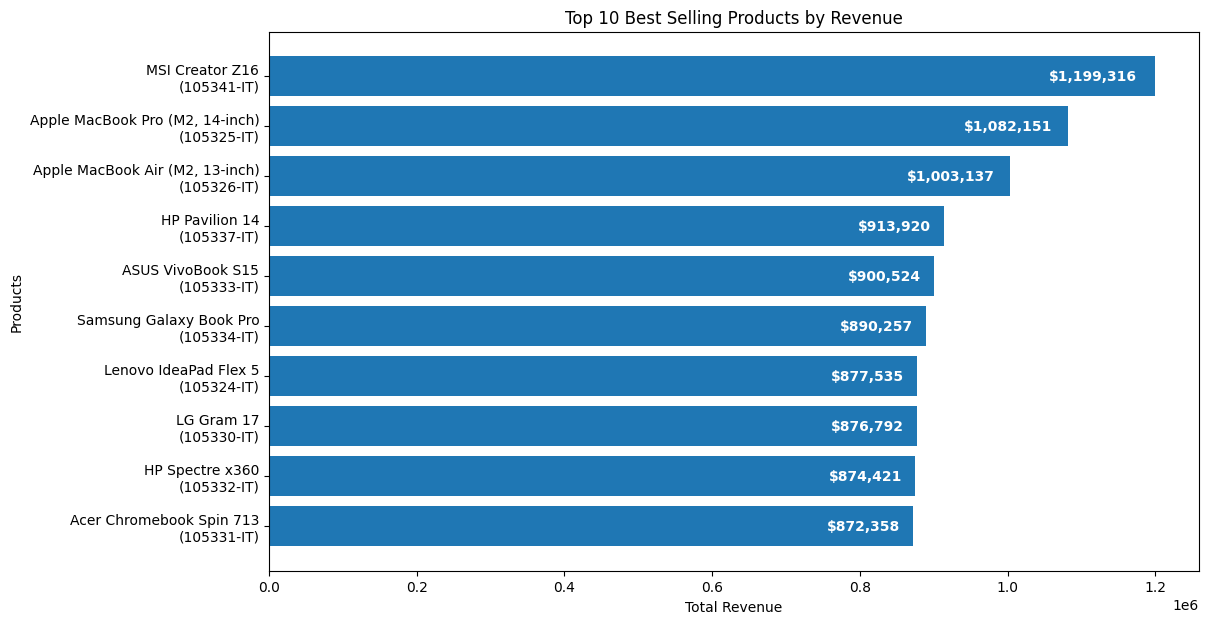

In [26]:
# only 10 products 
top_10_products = top_products.head(10)

# clean labels
top_10_products["Product Label"]=(
    top_10_products["Product"] + "\n(" +
    top_10_products["Prod Num"].astype(str) + ")")

#create figure
plt.figure(figsize=(12,7))

# Create horizontal chart
bars = plt.barh(
    top_10_products["Product Label"],
    top_10_products["Sale Amount"])

# put highest revenue on top
plt.gca().invert_yaxis()

# add title and labels
plt.title("Top 10 Best Selling Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Products")

# Add revenue inside bars
for bar in bars:
    width = bar.get_width()

    plt.text(
        width - (width * 0.02),  # just a little inside bar tip
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        ha="right",
        color="white",
        fontweight="bold")